Para el desarrollo de esta actividad, se va a escoger el data set Wine Quality de UC Irvine Machine Learning Repository. En esta tenemos dos datasets, relacionadas al vino, una de vino blanco y otra de vino rojo. Rvisando la documentación respectiva, el data set se importa de la siguiente manera.

# Instalar libreria e importarlas
Vamos a utilizar el comando pip para instalar la libreria correspondiente.

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# trear conjunto de datos
wine_quality = fetch_ucirepo(id=186)

# convertimos estos datos en DataFrames
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# Información de las variables
print(wine_quality.variables)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

# Revisar datos, variables, atributos y metodos.
Primero iniciamos haciendo un scooping de la información extraida para saber por donde empezar a filtrar la información, hacer un analisis y mostrar la información necesaria.

In [3]:
print(type(X))
print(type(y))
print(dir(X))
print(dir(y))
print(X.info())
print(y.info())

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__arrow_c_stream__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__dataframe_consortium_standard__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__po

In [4]:
print(X.head())
print(y.head())

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4  
   quali

Unimos el data frame X con el y, ya que ambas contienen el mismo numero de filas, esto con el fin de poder trabajar mas flexible y facil para el analisis de los datos

In [5]:
import pandas as pd

# Unir X y Y
df = pd.concat([X, y], axis=1)

# Tipos de datos y nulos
print(df.info())
print(df.isnull().sum())

# Estadísticos básicos
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB
None
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides        

/tmp/ipython-input-6-2768816588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='Set2')  # Agregar paleta de colores


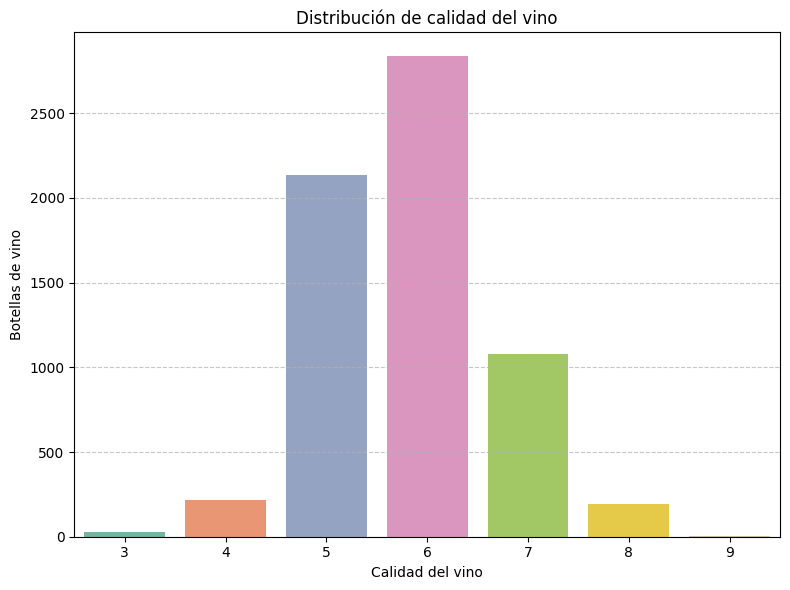

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=df, palette='Set2')  # Agregar paleta de colores

plt.title("Distribución de calidad del vino")
plt.xlabel("Calidad del vino")
plt.ylabel("Botellas de vino")
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Muestra la cuadrícula en el eje Y
plt.tight_layout()
plt.show()


In [7]:
import scipy.stats as stats

# Elegimos la variable que queremos evaluar respecto a quality
variable = 'alcohol'

# Creamos grupos por calidad
grupos = [df[df['quality'] == q][variable] for q in df['quality'].unique()]

# Prueba ANOVA de una vía
f_stat, p_value = stats.f_oneway(*grupos)

print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

if p_value < 0.05:
    print("Hay diferencias significativas en los niveles de alcohol entre las calidades de vino.")
else:
    print("No hay diferencias significativas en los niveles de alcohol entre las calidades de vino.")

Estadístico F: 320.5934
Valor p: 0.0000
Hay diferencias significativas en los niveles de alcohol entre las calidades de vino.


/tmp/ipython-input-8-4163901755.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=df, palette='Set3')


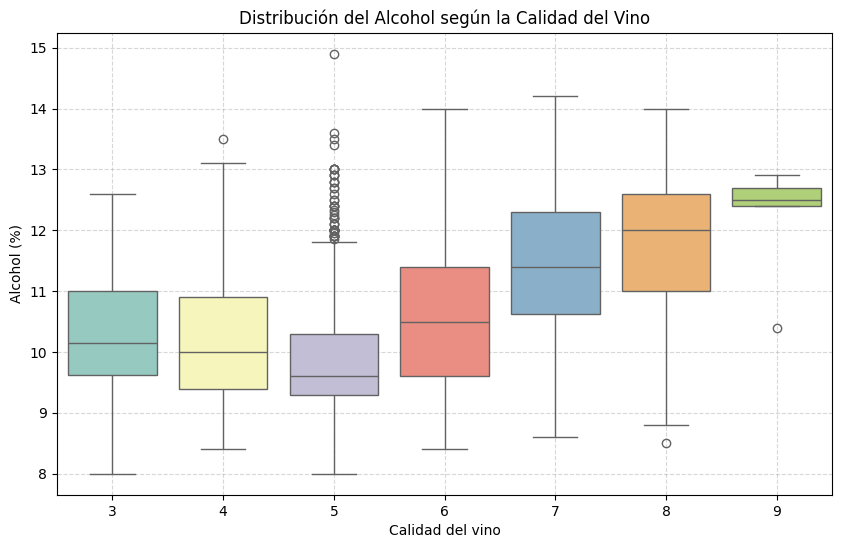

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=df, palette='Set3')
plt.title("Distribución del Alcohol según la Calidad del Vino")
plt.xlabel("Calidad del vino")
plt.ylabel("Alcohol (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

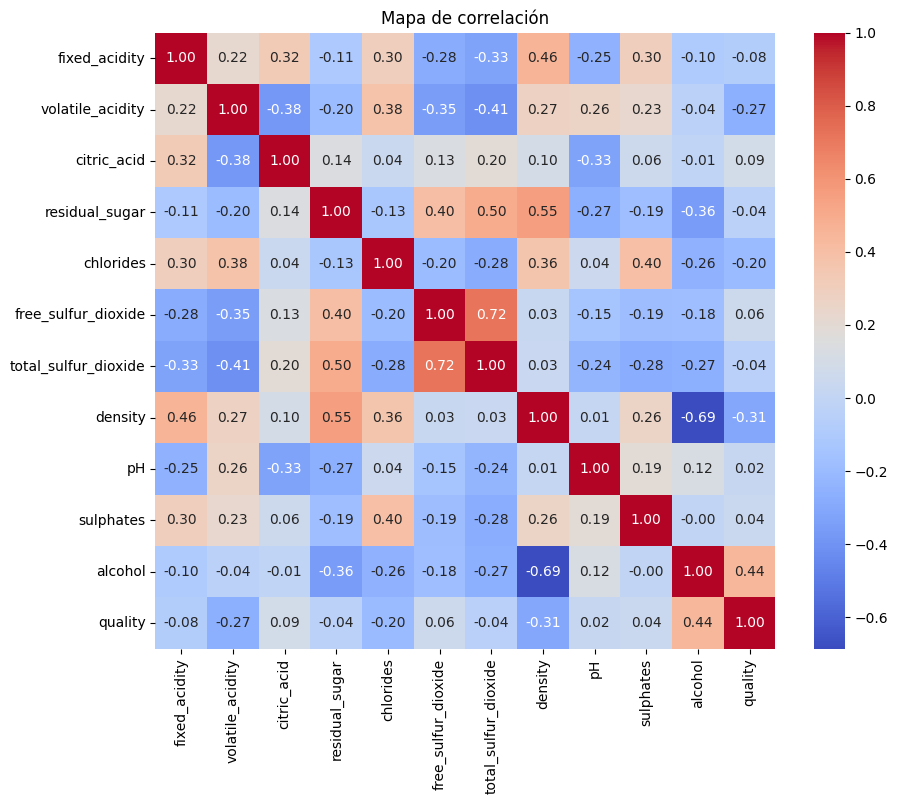

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Mapa de correlación")
plt.show()

### Matriz de correlaciones
Esta representado como un mapa de calor, cada celda muestra que tan relacionada esta una variable de otra. Donde los valores estan representado por:
 - +1: correlación positiva (aumenta una, aumenta la otra)
 - 0: no hay correlación
 - -1: correlación negativa (aumenta una, disminuye la otra)

 Una correlación positiva para este dataset puede ser entre la acidez volatil y la acidez fija, es decir, que si una aumenta la otra tambien.

 Por otro lado una correlación negativa puede ser la acides citrica y el ph, donde si incrementa la acides citrica el ph debe disminuir.

 Por ultimo donde no hay correlación puede ser entre las variables del alcohol y los sulfatos. Donde no hay una correlación directa.

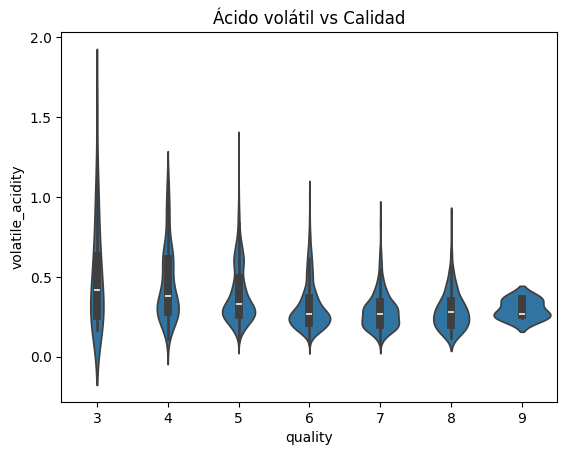

In [10]:
sns.violinplot(data=df, x='quality', y='volatile_acidity')
plt.title("Ácido volátil vs Calidad")
plt.show()

### Violin plot

Un violin plot es una combinación entre un boxplot (muestra la mediana, cuartiles y posibles valores extremos.) y distribución de densidad (indica cómo se distribuyen los datos a lo largo del eje y.)

En este caso estamos observando como se distribuye el acido volatil para cada tipo de calidad de vino. A medida que la calidad va incrementando, la distribucion es menos ancha.

Por lo que si el violin es más ancho en una zona del eje Y, significa que hay más vinos con esa cantidad de ácido volátil. si es estrecho, hay pocos vinos con ese valor.